# **Proyecto 2**

## **Analítica Computacional para la Toma de Decisiones**

### **Integrantes**:

**Juan Camilo Gómez - 202220238 - j.gomezu@uniandes.edu.co**

**Jerónimo Rueda - 202223775 - j.ruedar2@uniandes.edu.co**


### **Librerias**

In [45]:
import numpy as np
import pandas as pd  
import matplotlib.pyplot as plt
import seaborn as sns  
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import mlflow
import mlflow.sklearn
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import (mean_squared_error, mean_absolute_error, accuracy_score, precision_score, recall_score,f1_score, roc_auc_score, confusion_matrix, r2_score)
from sklearn.ensemble import RandomForestClassifier


### **Datos**

In [2]:
df = pd.read_csv("Saber 11 Datos Valle.csv")


mapaarreglo = {
    "Sin Estrato": 0,
    "Estrato 1": 1,
    "Estrato 2": 2,
    "Estrato 3": 3,
    "Estrato 4": 4,
    "Estrato 5": 5,
    "Estrato 6": 6
}

df["estrato_num"] = df["fami_estratovivienda"].map(mapaarreglo)


#df[df["fami_estratovivienda"]=="Sin Estrato"][["estrato_num", "fami_estratovivienda"]].head()

df[df["punt_lectura_critica"].isna()]["periodo"].value_counts()

df=df[df["punt_global"].notna()]
df=df.drop_duplicates()


df["estu_fechanacimiento"] = pd.to_datetime(
    df["estu_fechanacimiento"],
    format="%d/%m/%Y",
    errors="coerce"
)
df["estu_fechanacimiento"].isna().sum()

#df["estu_fechanacimiento"].describe()

#df.loc[641382, ["estu_fechanacimiento","periodo"]]

df["año"]=df["periodo"].astype(str).str[:4]



ti_menoresedad = pd.to_datetime("01/01/" + (df["año"].astype(int) - 17).astype(str),format="%d/%m/%Y")

cc_mayoresedad = pd.to_datetime("01/01/" + (df["año"].astype(int) - 18).astype(str),format="%d/%m/%Y")

reemplazofechanac = df["estu_fechanacimiento"].isna() | (df["estu_fechanacimiento"].dt.year == 1900)

df.loc[reemplazofechanac, "estu_fechanacimiento"] = np.where(
    df.loc[reemplazofechanac, "estu_tipodocumento"].eq("TI"),
    ti_menoresedad.loc[reemplazofechanac],
    cc_mayoresedad.loc[reemplazofechanac]
)
#df.loc[df["estu_fechanacimiento"].isna(), "estu_fechanacimiento"] = np.where(df["estu_tipodocumento"] == "TI",ti_menoresedad,cc_mayoresedad)
#df[df["estu_fechanacimiento"].isna()][["estu_fechanacimiento","periodo","estu_tipodocumento"]][["periodo","estu_tipodocumento"]].value_counts() 

df=df[df["año"].astype(int)>2014]

#print(df["estu_fechanacimiento"].sort_values().head(50))
#print(df["estu_fechanacimiento"].sort_values().tail(10))

reemplazos = {
    "CALIMA": "CALIMA EL DARIEN",
    "CALIMA (DARIEN)": "CALIMA EL DARIEN",
    "BUGA": "GUADALAJARA DE BUGA",
    "JAMUNDÍ": "JAMUNDI",
    "ALCALÁ": "ALCALA",
    "ANDALUCÍA": "ANDALUCIA",
    "BOLÍVAR": "BOLIVAR",
    "EL ÁGUILA": "EL AGUILA",
    "GUACARÍ": "GUACARI",
    "RIOFRÍO": "RIOFRIO",
    "LA UNIÓN": "LA UNION",
    "TULUÁ": "TULUA"
}

df["cole_mcpio_ubicacion"] = df["cole_mcpio_ubicacion"].replace(reemplazos)
print(df["cole_mcpio_ubicacion"].unique().tolist())

['CALI', 'GUADALAJARA DE BUGA', 'JAMUNDI', 'RESTREPO', 'BUENAVENTURA', 'CALIMA EL DARIEN', 'YUMBO', 'CANDELARIA', 'TULUA', 'PALMIRA', 'CARTAGO', 'BOLIVAR', 'DAGUA', 'EL CERRITO', 'ALCALA', 'ROLDANILLO', 'SAN PEDRO', 'LA CUMBRE', 'CAICEDONIA', 'FLORIDA', 'ZARZAL', 'OBANDO', 'TRUJILLO', 'ANDALUCIA', 'VIJES', 'RIOFRIO', 'VERSALLES', 'GINEBRA', 'PRADERA', 'LA VICTORIA', 'BUGALAGRANDE', 'SEVILLA', 'GUACARI', 'ANSERMANUEVO', 'LA UNION', 'EL DOVIO', 'TORO', 'ARGELIA', 'YOTOCO', 'ULLOA', 'EL AGUILA', 'EL CAIRO']


### **Faltantes**

In [3]:
#df.isna().sum()

df[["cole_cod_mcpio_ubicacion","estrato_num"]].groupby("cole_cod_mcpio_ubicacion").value_counts()
prom_estrato=(df.groupby("cole_cod_mcpio_ubicacion")["estrato_num"].transform("mean").round())

df["estrato_num"] = df["estrato_num"].fillna(prom_estrato).astype("Int64")
df["fami_estratovivienda"]=df["fami_estratovivienda"].fillna("Estrato"+prom_estrato.astype("string")).astype("string")

#print(prom_estrato)

#df[df["cole_bilingue"].isna()].describe()
#df[["cole_bilingue","estrato_num"]].groupby("cole_bilingue").value_counts()
df["cole_bilingue"] = df["cole_bilingue"].fillna("Desconocido")
df["cole_caracter"] = df["cole_caracter"].fillna("Desconocido")
df["cole_cod_dane_establecimiento"] = df["cole_cod_dane_establecimiento"].fillna("Desconocido (Instituto Tecnológico Gran Colombia)")
df["cole_area_ubicacion"] = df["cole_area_ubicacion"].fillna("RURAL")
df["cole_cod_dane_establecimiento"] = df["cole_area_ubicacion"].fillna("RURAL")
df["estu_cod_depto_presentacion"] = df["estu_cod_depto_presentacion"].fillna(df["estu_cod_reside_depto"])
df["estu_depto_presentacion"] = df["estu_depto_presentacion"].fillna(df["estu_depto_reside"])

df["estu_cod_mcpio_presentacion"] = df["estu_cod_mcpio_presentacion"].fillna(df["estu_cod_reside_mcpio"])
df["estu_cod_reside_depto"] = df["estu_cod_reside_depto"].fillna(df["cole_depto_ubicacion"])
df["estu_cod_reside_mcpio"] = df["estu_cod_reside_mcpio"].fillna(df["cole_mcpio_ubicacion"])
df["estu_depto_reside"] = df["estu_depto_reside"].fillna(df["estu_depto_presentacion"])
df["estu_genero"] = df["estu_genero"].fillna("Desconocido")
df["estu_mcpio_presentacion"] = df["estu_mcpio_presentacion"].fillna(df["cole_mcpio_ubicacion"])
df["estu_mcpio_reside"] = df["estu_mcpio_reside"].fillna(df["cole_mcpio_ubicacion"])

df["fami_cuartoshogar"] = df["fami_cuartoshogar"].fillna("Desconocido")
df["fami_educacionmadre"] = df["fami_educacionmadre"].fillna("Desconocido")
df["fami_educacionpadre"] = df["fami_educacionpadre"].fillna("Desconocido")
df["fami_personashogar"] = df["fami_personashogar"].fillna("Desconocido")
df["fami_tieneautomovil"] = df["fami_tieneautomovil"].fillna("No")
df["fami_tienecomputador"] = df["fami_tienecomputador"].fillna("No")
df["fami_tieneinternet"] = df["fami_tieneinternet"].fillna(df["fami_tienecomputador"])
df["fami_tienelavadora"] = df["fami_tienelavadora"].fillna("No")




#df[df["cole_area_ubicacion"].isna()].head()
#df[["cole_cod_dane_establecimiento","cole_cod_mcpio_ubicacion"]]["cole_cod_dane_establecimiento"].isna().groupby(df["cole_cod_mcpio_ubicacion"]).value_counts()
#df[df["cole_cod_dane_establecimiento"].isna()]["cole_nombre_establecimiento"].value_counts()
df[df["desemp_ingles"].isna()]["estrato_num"].value_counts()
#df["fami_tienecomputador"].value_counts()

corr_mat = df[["punt_ingles", "punt_matematicas", "punt_lectura_critica"]].corr()
c_mat = abs(corr_mat["punt_ingles"]["punt_matematicas"])
c_lec = abs(corr_mat["punt_ingles"]["punt_lectura_critica"])
suma_c = c_mat + c_lec
reemplazo = ((c_mat / suma_c) * df["punt_matematicas"] + (c_lec / suma_c) * df["punt_lectura_critica"])
df["punt_ingles"] = df["punt_ingles"].fillna(round(reemplazo, 0))


df[df["desemp_ingles"].isna()]["punt_ingles"].describe()



"""
if df["punt_ingles"]<27:

    df["desemp_ingles"]=df["desemp_ingles"].fillna("A1")

elif df["punt_ingles"]<=40:
    df["desemp_ingles"]=df["desemp_ingles"].fillna("A2")
elif df["punt_ingles"]<55:
    df["desemp_ingles"]=df["desemp_ingles"].fillna("B1")
else:
    df["desemp_ingles"]=df["desemp_ingles"].fillna("B+")
"""

condiciones = [df["punt_ingles"] < 27,df["punt_ingles"] <= 40,df["punt_ingles"] < 55]
valores = ["A1", "A2", "B1"]
#df["desemp_ingles"].value_counts()

nivel_calc = np.select(condiciones, valores, default="B+")

df["desemp_ingles"] = df["desemp_ingles"].fillna(pd.Series(nivel_calc, index=df.index))


categorias= df.columns.tolist()
df["estu_cod_reside_depto"].replace({'VALLE': 76}, inplace=True)
df["estu_cod_reside_mcpio"].replace({'CALI': 76001}, inplace=True)
df["estu_cod_reside_mcpio"].replace({'GUADALAJARA DE BUGA': 76111}, inplace=True)
df["estu_cod_reside_mcpio"].replace({'BUGALAGRANDE': 76113}, inplace=True)
df["estu_cod_reside_mcpio"].replace({'EL CERRITO': 76248}, inplace=True)
df["estu_cod_reside_mcpio"].replace({'JAMUNDÍ': 76364}, inplace=True)
df["estu_cod_reside_mcpio"].replace({'YUMBO': 76892}, inplace=True)
df["año"]=df["periodo"].astype(str).str[:4]

df=df[df["año"].astype(int)>2014]
df.isna().sum()


C:\Users\Juan Camilo Gómez\AppData\Local\Temp\ipykernel_13620\3873154715.py:82: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["estu_cod_reside_depto"].replace({'VALLE': 76}, inplace=True)
C:\Users\Juan Camilo Gómez\AppData\Local\Temp\ipykernel_13620\3873154715.py:82: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downca

periodo                          0
estu_tipodocumento               0
estu_consecutivo                 0
cole_area_ubicacion              0
cole_bilingue                    0
cole_calendario                  0
cole_caracter                    0
cole_cod_dane_establecimiento    0
cole_cod_dane_sede               0
cole_cod_depto_ubicacion         0
cole_cod_mcpio_ubicacion         0
cole_codigo_icfes                0
cole_depto_ubicacion             0
cole_genero                      0
cole_jornada                     0
cole_mcpio_ubicacion             0
cole_naturaleza                  0
cole_nombre_establecimiento      0
cole_nombre_sede                 0
cole_sede_principal              0
estu_cod_depto_presentacion      0
estu_cod_mcpio_presentacion      0
estu_cod_reside_depto            0
estu_cod_reside_mcpio            0
estu_depto_presentacion          0
estu_depto_reside                0
estu_estadoinvestigacion         0
estu_estudiante                  0
estu_fechanacimiento

### **Puntajes a Variables Categóricas**

In [28]:
puntajes=df.copy()


puntajes["Puntaje area ubicacion"] = puntajes["cole_area_ubicacion"].map({"URBANO": 1, "RURAL": 0})
puntajes["Puntaje bilingue"] = puntajes["cole_bilingue"].map({"S": 1, "N": 0})
#puntajes["Puntaje calendario"] = puntajes["cole_calendario"].map({"A": 1, "B": 2,"OTROS": 3})
#puntajes["Puntaje caracter"] = puntajes["cole_caracter"].map({"TÉCNICO/ACADÉMICO": 1, "ACADÉMICO": 2,"TÉCNICO": 3,"NO APLICA": 4})
puntajes["Puntaje Genero col"] = puntajes["cole_genero"].map({"MIXTO": 1, "FEMENINO": 2,"MASCULINO": 3})
puntajes["Puntaje Jornada"] = puntajes["cole_jornada"].map({"MAÑANA": 1, "TARDE": 2,"COMPLETA": 3,"NOCHE": 4,"UNICA": 5,"SABATINA":6})
puntajes["Puntaje Naturaleza"] = puntajes["cole_naturaleza"].map({"OFICIAL": 1, "NO OFICIAL": 0})
puntajes["Puntaje Sede Principal"] = puntajes["cole_sede_principal"].map({"S": 1, "N": 0})
puntajes["Puntaje Investigación"] = puntajes["estu_estadoinvestigacion"].map({"PUBLICAR": 3, "VALIDEZ OFICINA JURÍDICA": 2,"PRESENTE CON LECTURA TARDIA":1,"NO SE COMPROBO IDENTIDAD DEL EXAMINADO":0})
#puntajes["Puntaje Genero"] = puntajes["estu_genero"].map({"M": 0, "F": 1})
puntajes["Puntaje Libertad"] = puntajes["estu_privado_libertad"].map({"S": 0, "N": 1})
puntajes["Puntaje Cuartos Hogar"] = puntajes["fami_cuartoshogar"].map({"Uno": 1, "Dos": 2,"Tres": 3,"Cuatro": 4,"Cinco": 5,"Seis":6,"Seis o mas": 6.5,"Siete": 7,"Ocho": 8,"Nueve": 9,"Diez o más": 10})

puntajes["Puntaje Educación Madre"] = puntajes["fami_educacionmadre"].map({"No Aplica":0,"No sabe":1,"Ninguno":2,"Primaria incompleta":3,
                                                                           "Primaria completa":4,"Secundaria (Bachillerato) incompleta":5,
                                                                           "Secundaria (Bachillerato) completa":6,"Técnica o tecnológica completa":7,
                                                                           "Técnica o tecnológica incompleta":8,"Educación profesional incompleta":9,
                                                                           "Educación profesional completa":10,"Postgrado":11})

puntajes["Puntaje Educación Padre"] = puntajes["fami_educacionpadre"].map({"No Aplica":0,"No sabe":1,"Ninguno":2,"Primaria incompleta":3,
                                                                           "Primaria completa":4,"Secundaria (Bachillerato) incompleta":5,
                                                                           "Secundaria (Bachillerato) completa":6,"Técnica o tecnológica completa":7,
                                                                           "Técnica o tecnológica incompleta":8,"Educación profesional incompleta":9,
                                                                           "Educación profesional completa":10,"Postgrado":11})

puntajes["Puntaje Personas Hogar"] = puntajes["fami_personashogar"].map({"Una": 1, "1 a 2":1.5,"Dos": 2,"Tres": 3,"3 a 4":3.5,"Cuatro": 4,"Cinco": 5,
                                                                         "5 a 6":5.5,"Seis": 6,"Siete": 7,"7 a 8":7.5,"Ocho": 8,"Nueve": 9,"9 o más":9.5,
                                                                         "Diez": 10,"Doce o más": 10})
puntajes["Puntaje Automóvil"] = puntajes["fami_tieneautomovil"].map({"Si": 1, "No": 0})
puntajes["Puntaje Computador"] = puntajes["fami_tienecomputador"].map({"Si": 1, "No": 0})

puntajes["Puntaje Lavadora"] = puntajes["fami_tienelavadora"].map({"Si": 1, "No": 0})
puntajes["Puntaje Desempeño ingles"] = puntajes["desemp_ingles"].map({"A-":0,"A1": 1, "A2": 2,"B1": 3,"B+": 4})
puntajes["Puntaje Internet"] = puntajes["fami_tieneinternet"].map({"Si": 1, "No": 0})


puntajes["desemp_ingles"].value_counts()
def normalizar(s):
    return (s.str.normalize("NFKD")
                .str.encode("ascii","ignore")
                .str.decode("utf-8").str.upper()
                .str.strip())
puntajes["cole_mcpio_ubicacion"] = (df["cole_mcpio_ubicacion"].pipe(normalizar))
puntajes["cole_mcpio_ubicacion"] = puntajes["cole_mcpio_ubicacion"].replace(["CALIMA (DARIEN)", "CALIMA"], "CALIMA EL DARIEN")
mapazonas= {
    # Zona Pacífico 
    "BUENAVENTURA": "Pacífico",
    # Zona Centro
    "CALIMA EL DARIEN": "Centro",
    "YOTOCO": "Centro",
    "SAN PEDRO": "Centro",
    "GUADALAJARA DE BUGA": "Centro",   
    "BUGA": "Centro",                  
    "GUACARI": "Centro",
    "GINEBRA": "Centro",
    "EL CERRITO": "Centro",
    # Zona Sur 
    "DAGUA": "Sur",
    "LA CUMBRE": "Sur",
    "VIJES": "Sur",
    "YUMBO": "Sur",
    "CALI": "Sur",
    "PALMIRA": "Sur",
    "CANDELARIA": "Sur",
    "PRADERA": "Sur",
    "FLORIDA": "Sur",
    "JAMUNDI": "Sur",
    "RESTREPO": "Sur",
    # Zona Norte
    "ALCALA": "Norte",
    "ULLOA": "Norte",
    "CARTAGO": "Norte",
    "ANSERMANUEVO": "Norte",
    "EL AGUILA": "Norte",
    "EL CAIRO": "Norte",
    "VERSALLES": "Norte",
    "ARGELIA": "Norte",
    "TORO": "Norte",
    "OBANDO": "Norte",
    "LA VICTORIA": "Norte",
    "LA UNION": "Norte",
    "ROLDANILLO": "Norte",
    "ZARZAL": "Norte",
    "BOLIVAR": "Norte",
    "TRUJILLO": "Norte",
    "RIOFRIO": "Norte",
    "EL DOVIO": "Norte",
    "ANDALUCIA": "Norte",
    "BUGALAGRANDE": "Norte",
    "TULUA": "Norte",
    "SEVILLA": "Norte",
    "CAICEDONIA": "Norte"}

puntajes["Zona"] = puntajes["cole_mcpio_ubicacion"].map(mapazonas)

puntajes["Puntaje bilingue"].fillna(puntajes["Puntaje bilingue"].mode()[0],inplace=True)
ordenlogico = ["Puntaje Educación Madre","Puntaje Educación Padre","Puntaje Personas Hogar","Puntaje Cuartos Hogar"]
for col in ordenlogico:
    puntajes[col] = puntajes[col].fillna(puntajes.groupby("fami_estratovivienda")[col].transform("mean"))
puntajes["año"] = puntajes["año"].astype(int)
puntajes["Puntaje educacion padres"] = puntajes["Puntaje Educación Padre"]+puntajes["Puntaje Educación Madre"]
puntajes["Puntaje recursos hogar"] = puntajes["Puntaje Automóvil"]+puntajes["Puntaje Computador"]+puntajes["Puntaje Lavadora"]
#puntajes["Puntaje Genero"] = puntajes["estu_genero"].map({"M": 0, "F": 1})
puntajes_solonum = puntajes.iloc[:, 45:].copy()
puntajes2020s=puntajes[puntajes["año"].astype(int)>=2020]




print("Nuevas columnas listas:", ["Puntaje Caracter","Puntaje Calendario",
    "int_estrato_edu","int_urbano_estrato","int_natur_estrato"])

C:\Users\Juan Camilo Gómez\AppData\Local\Temp\ipykernel_13620\4131201112.py:99: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  puntajes["Puntaje bilingue"].fillna(puntajes["Puntaje bilingue"].mode()[0],inplace=True)


Nuevas columnas listas: ['Puntaje Caracter', 'Puntaje Calendario', 'int_estrato_edu', 'int_urbano_estrato', 'int_natur_estrato']


In [29]:
columnas=puntajes2020s.columns
for i in columnas:
    print(f"Columna:{i} , Ejemplo: {puntajes2020s[i][2]}")

Columna:periodo , Ejemplo: 20224
Columna:estu_tipodocumento , Ejemplo: TI
Columna:estu_consecutivo , Ejemplo: SB11202240151458
Columna:cole_area_ubicacion , Ejemplo: URBANO
Columna:cole_bilingue , Ejemplo: N
Columna:cole_calendario , Ejemplo: A
Columna:cole_caracter , Ejemplo: TÉCNICO/ACADÉMICO
Columna:cole_cod_dane_establecimiento , Ejemplo: URBANO
Columna:cole_cod_dane_sede , Ejemplo: 176364001313.0
Columna:cole_cod_depto_ubicacion , Ejemplo: 76
Columna:cole_cod_mcpio_ubicacion , Ejemplo: 76364
Columna:cole_codigo_icfes , Ejemplo: 671156.0
Columna:cole_depto_ubicacion , Ejemplo: VALLE
Columna:cole_genero , Ejemplo: MIXTO
Columna:cole_jornada , Ejemplo: UNICA
Columna:cole_mcpio_ubicacion , Ejemplo: JAMUNDI
Columna:cole_naturaleza , Ejemplo: OFICIAL
Columna:cole_nombre_establecimiento , Ejemplo: INSTITUCION EDUCATIVA TÉCNICA INDUSTRIAL ESPAÑA
Columna:cole_nombre_sede , Ejemplo: TÉCNICA INDUSTRIAL ESPAÑA-SEDE PRINCIPAL
Columna:cole_sede_principal , Ejemplo: S
Columna:estu_cod_depto_pres

In [6]:
semilla = 42

tamaño_test = 0.2
porcentaje=tamaño_test/(1-tamaño_test)

In [109]:
mapa_clase_madre = {0:0, 1:0, 2:0, 3:0,4:1, 5:1, 6:1,7:2, 8:2,9:3, 10:3, 11:3}      


nombres_clase = ["Básica/Sin","Secundaria","Técnica","Superior"]

puntajes2020s["clase_madre"] = puntajes2020s["Puntaje Educación Madre"].round().astype(int).map(mapa_clase_madre)

Conj_num = ["Puntaje Personas Hogar",
            "Puntaje Automóvil","Puntaje Computador","Puntaje Lavadora",
            "punt_ingles", "punt_matematicas","punt_sociales_ciudadanas", "punt_c_naturales","punt_lectura_critica",
            "Puntaje Desempeño ingles","Puntaje bilingue","clase_madre","Puntaje Internet"]

#Conj_cat = []

# Mantenemos cole_mcpio_ubicacion como CLAVE (no como dummy) para hacer target encoding
base = puntajes2020s[Conj_num].copy()
#base["año"] = base["año"].astype(int)
y = base["clase_madre"].astype(int).values
y_separado = pd.qcut(y, q=10, labels=False, duplicates='drop')

idx_trainval, idx_test = train_test_split(np.arange(len(base)), test_size=0.15,
                                          random_state=semilla, stratify=y_separado)
idx_train, idx_val = train_test_split(idx_trainval, test_size=porcentaje,
                                      random_state=semilla, stratify=y_separado[idx_trainval])

# Target encoding del municipio — SOLO con train, con smoothing
mu_global = y[idx_train].mean()
X = base[Conj_num].drop(columns=["clase_madre"])
y = base["clase_madre"].astype(int).values 

idx_trainval, idx_test = train_test_split(np.arange(len(base)), test_size=0.15,
                                          random_state=semilla, stratify=y)
idx_train, idx_val = train_test_split(idx_trainval, test_size=porcentaje,
                                      random_state=semilla, stratify=y[idx_trainval])

X_train, X_val, X_test = X.iloc[idx_train], X.iloc[idx_val], X.iloc[idx_test]
X_escalar = StandardScaler()
X_train_s = X_escalar.fit_transform(X_train)
X_val_s   = X_escalar.transform(X_val)
X_test_s  = X_escalar.transform(X_test)

y_train, y_val, y_test = y[idx_train], y[idx_val], y[idx_test]
mapeo_educacion = {
    "Básica/Sin": 0, "Secundaria": 1, "Técnica": 2, "Superior": 3}
base["Puntaje Educación Madre"] = puntajes2020s["fami_educacionmadre"].map(mapeo_educacion).astype(float)
etiquetas_madre = [k for k in mapeo_educacion.keys()]


C:\Users\Juan Camilo Gómez\AppData\Local\Temp\ipykernel_13620\3567679680.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  puntajes2020s["clase_madre"] = puntajes2020s["Puntaje Educación Madre"].round().astype(int).map(mapa_clase_madre)


In [110]:
from sklearn.metrics import (accuracy_score, f1_score, precision_score, recall_score,
                             confusion_matrix, classification_report, roc_auc_score)

def evaluar_clasif(y_true, y_pred, y_proba=None, label=''):
    acc  = accuracy_score(y_true, y_pred)
    f1m  = f1_score(y_true, y_pred, average='macro')
    adj  = np.mean(np.abs(y_true - y_pred) <= 1)   # ordinal: ±1 clase
    out = {"Accuracy":acc, "F1_macro":f1m, "Adj_Acc_±1":adj}
    if y_proba is not None and len(np.unique(y_true))==y_proba.shape[1]:
        out["AUC_ovr"] = roc_auc_score(y_true, y_proba, multi_class='ovr', average='macro')
    if label:
        print(f"  [{label}]  Acc={acc:.3f} | F1m={f1m:.3f} | Adj±1={adj:.3f}"
              + (f" | AUC={out['AUC_ovr']:.3f}" if 'AUC_ovr' in out else ""))
    return out

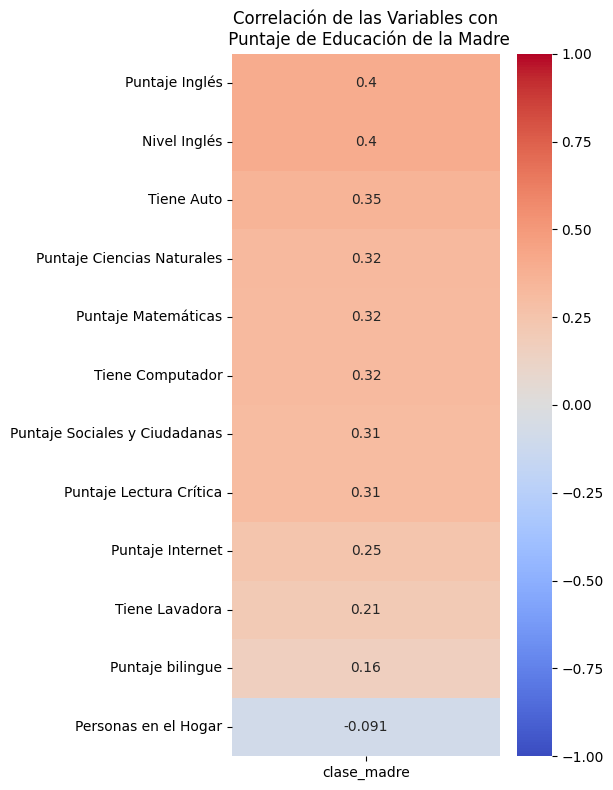

In [129]:
plt.figure(figsize=(6, 8))
basee=base[Conj_num].copy()
basee.rename(columns={"punt_ingles": "Puntaje Inglés", "punt_matematicas": "Puntaje Matemáticas"
                      , "punt_sociales_ciudadanas": "Puntaje Sociales y Ciudadanas", "punt_c_naturales": "Puntaje Ciencias Naturales", "punt_lectura_critica": "Puntaje Lectura Crítica",
                      "Puntaje Automóvil": "Tiene Auto","Puntaje Computador": "Tiene Computador", "Puntaje Lavadora": "Tiene Lavadora",
                      "Puntaje Desempeño ingles": "Nivel Inglés","Puntaje Personas Hogar": "Personas en el Hogar"}, inplace=True)
matriz_completa = basee.corr()

#Solo se usa el puntaje de educacion de la madre
corr_madre = matriz_completa[["clase_madre"]].drop("clase_madre", axis=0)
corr_madre_ordenada = corr_madre.sort_values(by="clase_madre", ascending=False)
sns.heatmap(corr_madre_ordenada, annot=True, cmap='coolwarm', vmin=-1, vmax=1, cbar=True)

plt.title('Correlación de las Variables con\n Puntaje de Educación de la Madre')
plt.tight_layout()
plt.show()

C:\Users\Juan Camilo Gómez\AppData\Local\Temp\ipykernel_13620\125737455.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='clase_madre', data=base, palette='viridis')


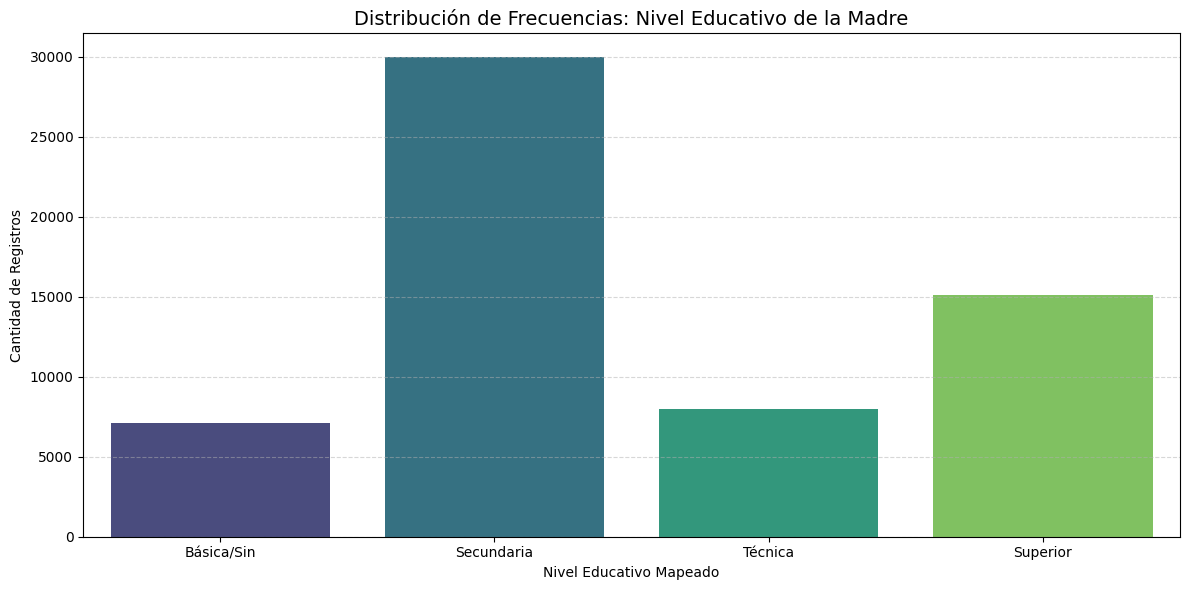

In [114]:
plt.figure(figsize=(12, 6))

# Usamos countplot ya que la variable actúa ahora como un indicador entero discreto
sns.countplot(x='clase_madre', data=base, palette='viridis')
plt.title('Distribución de Frecuencias: Nivel Educativo de la Madre', fontsize=14)
plt.xlabel('Nivel Educativo Mapeado')
plt.ylabel('Cantidad de Registros')
# Cambiar los números del eje X con las categorías originales 
plt.xticks(ticks=range(4), labels=etiquetas_madre)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

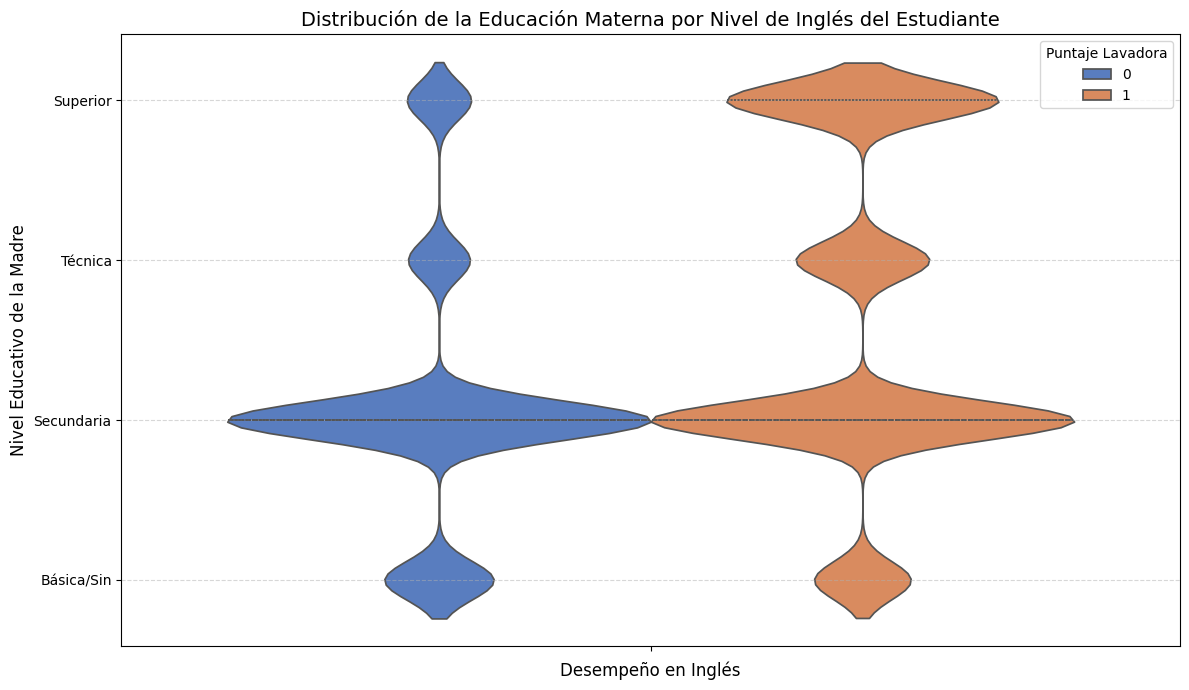

In [122]:
plt.figure(figsize=(12, 7))

sns.violinplot(hue="Puntaje Lavadora", y='clase_madre', data=base, 
               palette='muted', inner="quartile")

plt.title('Distribución de la Educación Materna por Nivel de Inglés del Estudiante', fontsize=14)
plt.xlabel('Desempeño en Inglés', fontsize=12)
plt.ylabel('Nivel Educativo de la Madre', fontsize=12)

# Ajustamos las etiquetas del eje Y para mapear los números de vuelta a su texto original
plt.yticks(ticks=range(4), labels=etiquetas_madre, fontsize=10)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

In [124]:
from sklearn.metrics import accuracy_score, f1_score

mlflow.set_tracking_uri("file:./mlruns")
experimento = mlflow.set_experiment("Puntaje Prueba Saber: Pregunta Educación Madre")
n_feats = X_train.shape[1]

for n_est in [100, 300, 500]:
    for max_d in [8, 12, 16]:
        for max_f in ["sqrt", min(8, n_feats)]:
            for min_leaf in [2, 5, 20]:
                with mlflow.start_run(experiment_id=experimento.experiment_id):
                    rf = RandomForestClassifier(
                        n_estimators=n_est, max_depth=max_d, max_features=max_f,
                        min_samples_leaf=min_leaf,
                        n_jobs=-1, random_state=semilla)
                    rf.fit(X_train, y_train)
                    pred_val = rf.predict(X_val)
                    acc = accuracy_score(y_val, pred_val)
                    f1m = f1_score(y_val, pred_val, average='macro')
                    adj = np.mean(np.abs(y_val - pred_val) <= 1)
                    mlflow.set_tag("mlflow.runName", f"RFC_{n_est}_{max_d}_{max_f}_leaf{min_leaf}")
                    mlflow.log_params({"n_estimators":n_est,"max_depth":max_d,
                                       "max_features":str(max_f),"min_samples_leaf":min_leaf})
                    mlflow.log_metrics({"Accuracy_val":acc,"F1_macro_val":f1m,"Adj_Acc_val":adj})
                    mlflow.sklearn.log_model(rf, "random_forest_model")

2026/05/24 13:11:44 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/24 13:11:44 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/05/24 13:11:55 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/24 13:11:55 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_p

In [132]:
import mlflow

# 1. Conectarse al experimento
mlflow.set_tracking_uri("file:./mlruns")
experimento = mlflow.get_experiment_by_name("Puntaje Prueba Saber: Pregunta Educación Madre")

# 2. Descargar todos los runs de este experimento en un DataFrame
runs_df = mlflow.search_runs(experiment_ids=[experimento.experiment_id])

# 3. Ordenar por la métrica que te interese (ej. F1_macro_val o Accuracy_val) de forma descendente
# Nota: MLflow le añade el prefijo "metrics." a las columnas de métricas
mejor_run = runs_df.sort_values(by="metrics.F1_macro_val", ascending=False).iloc[0]

# 4. Mostrar los mejores resultados
print("¡Mejor Run Encontrado!")
print(f"Nombre del Run: {mejor_run['tags.mlflow.runName']}")
print(f"Mejor F1 Macro: {mejor_run['metrics.F1_macro_val']:.4f}")
print(f"Mejor Accuracy: {mejor_run['metrics.Accuracy_val']:.4f}")
print("-" * 30)
print("Parámetros del mejor modelo:")
print(f"- n_estimators: {mejor_run['params.n_estimators']}")
print(f"- max_depth: {mejor_run['params.max_depth']}")
print(f"- max_features: {mejor_run['params.max_features']}")
print(f"- min_samples_leaf: {mejor_run['params.min_samples_leaf']}")

¡Mejor Run Encontrado!
Nombre del Run: RFC_300_16_8_leaf2
Mejor F1 Macro: 1.0000
Mejor Accuracy: 1.0000
------------------------------
Parámetros del mejor modelo:
- n_estimators: 300
- max_depth: 16
- max_features: 8
- min_samples_leaf: 2


In [133]:
n_estimators=mejor_run['params.n_estimators']
max_depth=mejor_run['params.max_depth']
max_features=mejor_run['params.max_features']
min_samples_leaf=mejor_run['params.min_samples_leaf']
with mlflow.start_run(experiment_id=experimento.experiment_id):
    rf = RandomForestClassifier(
        n_estimators=n_est, max_depth=max_d, max_features=max_f,
        min_samples_leaf=min_leaf,
        n_jobs=-1, random_state=semilla)
    rf.fit(X_train, y_train)
    pred_val = rf.predict(X_val)
    acc = accuracy_score(y_val, pred_val)
    f1m = f1_score(y_val, pred_val, average='macro')
    adj = np.mean(np.abs(y_val - pred_val) <= 1)
    mlflow.set_tag("mlflow.runName", f"RFC_{n_est}_{max_d}_{max_f}_leaf{min_leaf}")
    mlflow.log_params({"n_estimators":n_est,"max_depth":max_d,
                        "max_features":str(max_f),"min_samples_leaf":min_leaf})
    mlflow.log_metrics({"Accuracy_val":acc,"F1_macro_val":f1m,"Adj_Acc_val":adj})
    mlflow.sklearn.log_model(rf, "random_forest_model")

2026/05/24 14:11:11 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/24 14:11:11 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


In [135]:
import mlflow

# 1. Conectarse al experimento
mlflow.set_tracking_uri("file:./mlruns")
experimento = mlflow.get_experiment_by_name("Puntaje Prueba Saber: Pregunta Educación Madre")

# 2. Descargar todos los runs de este experimento en un DataFrame
runs_df = mlflow.search_runs(experiment_ids=[experimento.experiment_id])

# 3. Ordenar por la métrica que te interese (ej. F1_macro_val o Accuracy_val) de forma descendente
# Nota: MLflow le añade el prefijo "metrics." a las columnas de métricas
mejor_run = runs_df.sort_values(by="metrics.Accuracy_val", ascending=False).iloc[0]

# 4. Mostrar los mejores resultados
print(f"Mejor Resultado y nus parámetros:\n\nNombre del Run: {mejor_run['tags.mlflow.runName']}")
print(f"Mejor F1 Macro: {mejor_run['metrics.F1_macro_val']:.4f}")
print(f"Mejor Accuracy: {mejor_run['metrics.Accuracy_val']:.4f}")
print("-" * 30)
print("Parámetros del mejor modelo:")
print(f"- n_estimators: {mejor_run['params.n_estimators']}")
print(f"- max_depth: {mejor_run['params.max_depth']}")
print(f"- max_features: {mejor_run['params.max_features']}")
print(f"- min_samples_leaf: {mejor_run['params.min_samples_leaf']}")

Mejor Resultado y nus parámetros:

Nombre del Run: RFC_300_16_8_leaf5
Mejor F1 Macro: 1.0000
Mejor Accuracy: 1.0000
------------------------------
Parámetros del mejor modelo:
- n_estimators: 300
- max_depth: 16
- max_features: 8
- min_samples_leaf: 5


In [125]:
from sklearn.metrics import (accuracy_score, f1_score, precision_score, recall_score,
                             roc_auc_score, confusion_matrix, classification_report,
                             ConfusionMatrixDisplay)

mlflow.set_tracking_uri("file:./mlruns")
experimento = mlflow.set_experiment("Puntaje Prueba Saber: Pregunta Educación Madre - Matriz")

def evaluar_clasif(y_true, y_pred, y_proba=None, label=''):
    acc = accuracy_score(y_true, y_pred)
    f1m = f1_score(y_true, y_pred, average='macro')
    adj = float(np.mean(np.abs(y_true - y_pred) <= 1))
    out = {'Accuracy': acc, 'F1_macro': f1m, 'Adj_Acc_pm1': adj}
    if y_proba is not None and y_proba.shape[1] == len(np.unique(y_true)):
        out['AUC_ovr'] = roc_auc_score(y_true, y_proba, multi_class='ovr', average='macro')
    if label:
        msg = f'  [{label}]  Acc={acc:.3f} | F1m={f1m:.3f} | Adj_pm1={adj:.3f}'
        if 'AUC_ovr' in out: msg += f' | AUC={out["AUC_ovr"]:.3f}'
        print(msg)
    return out

def plot_diagnostico(y_true, y_pred, titulo, nombres=None):
    cm = confusion_matrix(y_true, y_pred, normalize='true')
    fig, ax = plt.subplots(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='.2f', cmap='Blues',
                xticklabels=nombres, yticklabels=nombres, ax=ax)
    ax.set_xlabel('Predicho'); ax.set_ylabel('Real')
    ax.set_title(f'{titulo} — Matriz de confusión normalizada')
    plt.tight_layout(); plt.show()

=== Baseline: Random Forest Classifier ===
  [VAL ]  Acc=0.581 | F1m=0.317 | Adj_pm1=0.817 | AUC=0.696
  [TEST]  Acc=0.584 | F1m=0.319 | Adj_pm1=0.819 | AUC=0.702


2026/05/24 13:42:21 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


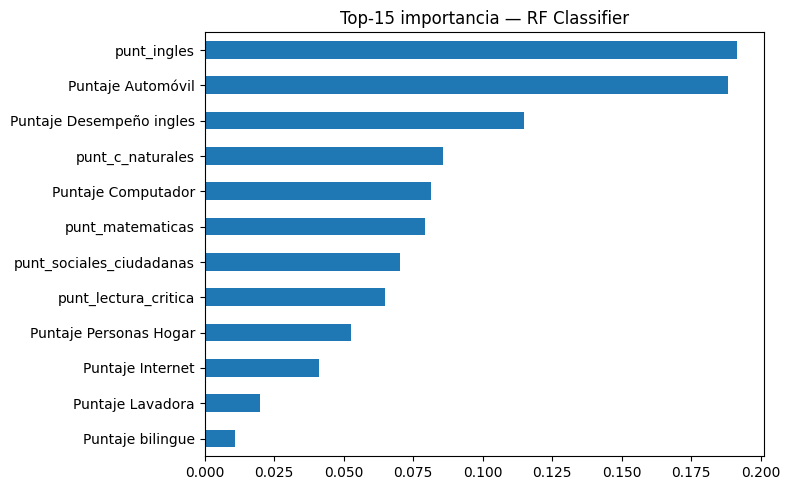

In [127]:

print('=== Baseline: Random Forest Classifier ===')
with mlflow.start_run(run_name='RFC_baseline') as run:
    rf_params = dict(n_estimators=400, max_depth=14, min_samples_leaf=20,
                     n_jobs=-1, random_state=semilla)
    rf = RandomForestClassifier(**rf_params)
    rf.fit(X_train, y_train)
    pred_val   = rf.predict(X_val);    proba_val   = rf.predict_proba(X_val)
    pred_test  = rf.predict(X_test);   proba_test  = rf.predict_proba(X_test)
    m_val  = evaluar_clasif(y_val,  pred_val,  proba_val,  'VAL ')
    m_test = evaluar_clasif(y_test, pred_test, proba_test, 'TEST')
    mlflow.log_params({**rf_params, 'model_type':'RFClassifier', 'n_features':X.shape[1]})
    for k,v in m_val.items():  mlflow.log_metric(f'val_{k}', v)
    for k,v in m_test.items(): mlflow.log_metric(f'test_{k}', v)
    mlflow.sklearn.log_model(rf, name='rfc_model')

# Importancia
imp = pd.Series(rf.feature_importances_, index=X.columns).sort_values().tail(15)
fig, ax = plt.subplots(figsize=(8,5)); imp.plot(kind='barh', ax=ax)
ax.set_title('Top-15 importancia — RF Classifier'); plt.tight_layout(); plt.show()

In [131]:
n_clases = int(y_train.max()) + 1

def hacer_redesneu(dimensiones, n_clases, ocultas=(256,128,64), dropout=0.25, l2=5e-4, lr=8e-4):
    inputs = tf.keras.Input(shape=(dimensiones,))
    x = tf.keras.layers.BatchNormalization()(inputs)
    for h in ocultas:
        x = tf.keras.layers.Dense(h, kernel_regularizer=tf.keras.regularizers.l2(l2))(x)
        x = tf.keras.layers.BatchNormalization()(x)
        x = tf.keras.layers.Activation('relu')(x)
        x = tf.keras.layers.Dropout(dropout)(x)
    out = tf.keras.layers.Dense(n_clases, activation='softmax')(x)
    modelo = tf.keras.Model(inputs, out)
    modelo.compile(optimizer=tf.keras.optimizers.Adam(lr),
                   loss='sparse_categorical_crossentropy',
                   metrics=['accuracy'])
    return modelo

prueba = [
    {'Nombre':'NN_BN_pequeña', 'Capas Ocultas':(128,64),'dropout':0.20,'l2':1e-4,'lr':1e-3,'epochs':80, 'bs':256},
    {'Nombre':'NN_BN_mediana', 'Capas Ocultas':(256,128,64),'dropout':0.25,'l2':5e-4,'lr':8e-4,'epochs':120,'bs':256},
    {'Nombre':'NN_BN_grande',  'Capas Ocultas':(512,256,128,64),'dropout':0.30,'l2':1e-3,'lr':5e-4,'epochs':150,'bs':512}]

resultados, histories, models = [], {}, {}

for cfg in prueba:
    print(f'\n=== {cfg["Nombre"]} ===')
    tf.keras.backend.clear_session()
    tf.random.set_seed(semilla); np.random.seed(semilla)
    with mlflow.start_run(run_name=cfg['Nombre']) as run:
        model = hacer_redesneu(X_train_s.shape[1], n_clases,
                               cfg['Capas Ocultas'], cfg['dropout'], cfg['l2'], cfg['lr'])

        es = tf.keras.callbacks.EarlyStopping(patience=15, restore_best_weights=True, monitor='val_loss')
        rl = tf.keras.callbacks.ReduceLROnPlateau(patience=6, factor=0.5, monitor='val_loss', min_lr=1e-5)

        hist = model.fit(
            X_train_s, y_train,                          # ← y entero, no escalado
            validation_data=(X_val_s, y_val),
            epochs=cfg['epochs'], batch_size=cfg['bs'],
            callbacks=[es, rl], verbose=0)

        # Predicciones: probabilidades → clase con argmax
        proba_val  = model.predict(X_val_s,  verbose=0)
        proba_test = model.predict(X_test_s, verbose=0)
        pred_val   = proba_val.argmax(1)
        pred_test  = proba_test.argmax(1)

        m_val  = evaluar_clasif(y_val,  pred_val,  proba_val,  'VAL ')
        m_test = evaluar_clasif(y_test, pred_test, proba_test, 'TEST')

        mlflow.log_params({
            'model_type':'NeuralNetwork_Classifier',
            'hidden': str(cfg['Capas Ocultas']),
            'dropout': cfg['dropout'], 'l2': cfg['l2'], 'lr': cfg['lr'],
            'batch_size': cfg['bs'], 'epochs_max': cfg['epochs'],
            'epochs_trained': len(hist.history['loss']),
            'n_features': X.shape[1], 'n_clases': n_clases,
            'optimizer':'Adam', 'early_stopping': True
        })
        for k,v in m_val.items():  mlflow.log_metric(f'val_{k}', v)
        for k,v in m_test.items(): mlflow.log_metric(f'test_{k}', v)
        mlflow.tensorflow.log_model(model, name='Modelo Redes Neuronales')

        resultados.append({
            'modelo': cfg['Nombre'],
            **{f'val_{k}':v for k,v in m_val.items()},
            **{f'test_{k}':v for k,v in m_test.items()},
            'epochs_trained': len(hist.history['loss'])})
        histories[cfg['Nombre']] = hist
        models[cfg['Nombre']]    = model


=== NN_BN_pequeña ===


c:\Users\Juan Camilo Gómez\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\backend\tensorflow\core.py:171: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  return np.array(x)


  [VAL ]  Acc=0.581 | F1m=0.318 | Adj_pm1=0.817 | AUC=0.699
  [TEST]  Acc=0.583 | F1m=0.319 | Adj_pm1=0.818 | AUC=0.702


2026/05/24 13:57:26 WARNING mlflow.tensorflow: You are saving a TensorFlow Core model or Keras model without a signature. Inference with mlflow.pyfunc.spark_udf() will not work unless the model's pyfunc representation accepts pandas DataFrames as inference inputs.
c:\Users\Juan Camilo Gómez\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\backend\tensorflow\core.py:171: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  return np.array(x)



=== NN_BN_mediana ===
  [VAL ]  Acc=0.580 | F1m=0.317 | Adj_pm1=0.816 | AUC=0.699
  [TEST]  Acc=0.585 | F1m=0.320 | Adj_pm1=0.819 | AUC=0.701


2026/05/24 14:02:38 WARNING mlflow.tensorflow: You are saving a TensorFlow Core model or Keras model without a signature. Inference with mlflow.pyfunc.spark_udf() will not work unless the model's pyfunc representation accepts pandas DataFrames as inference inputs.
c:\Users\Juan Camilo Gómez\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\backend\tensorflow\core.py:171: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  return np.array(x)



=== NN_BN_grande ===
  [VAL ]  Acc=0.581 | F1m=0.318 | Adj_pm1=0.816 | AUC=0.700
  [TEST]  Acc=0.583 | F1m=0.320 | Adj_pm1=0.816 | AUC=0.703


2026/05/24 14:07:32 WARNING mlflow.tensorflow: You are saving a TensorFlow Core model or Keras model without a signature. Inference with mlflow.pyfunc.spark_udf() will not work unless the model's pyfunc representation accepts pandas DataFrames as inference inputs.
c:\Users\Juan Camilo Gómez\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\backend\tensorflow\core.py:171: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  return np.array(x)


=== Comparativa final ===
       modelo  val_Accuracy  val_F1_macro  val_Adj_Acc_pm1  val_AUC_ovr  test_Accuracy  test_F1_macro  test_Adj_Acc_pm1  test_AUC_ovr  epochs_trained
 RFC_baseline      0.437725      0.404596         0.835081     0.710720       0.438213       0.404559          0.842624      0.718254             NaN
NN_BN_pequeña      0.390549      0.379304         0.829682     0.709675       0.398426       0.385740          0.837859      0.717575            75.0
NN_BN_mediana      0.379987      0.370424         0.823580     0.708401       0.391001       0.379376          0.832207      0.714674            85.0
 NN_BN_grande      0.370756      0.364992         0.825771     0.708017       0.376815       0.369880          0.834977      0.713870            83.0

>>> Mejor modelo por F1 macro en TEST: RFC_baseline


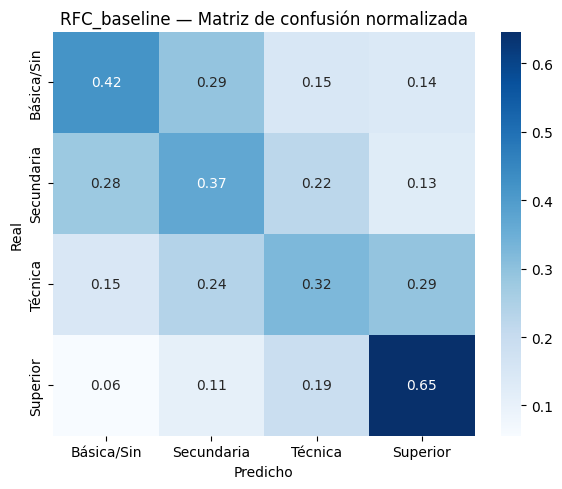


=== Reporte por clase ===
              precision    recall  f1-score   support

  Básica/Sin      0.221     0.419     0.289      1062
  Secundaria      0.665     0.368     0.474      4495
     Técnica      0.196     0.324     0.245      1202
    Superior      0.578     0.646     0.610      2264

    accuracy                          0.438      9023
   macro avg      0.415     0.440     0.405      9023
weighted avg      0.528     0.438     0.456      9023


Desempeño por estrato (TEST):
              n  Accuracy  Adj_Acc_±1  clase_modal_real  clase_modal_pred
estrato                                                                  
0         154.0     0.305       0.818               1.0               0.0
1        1690.0     0.310       0.879               1.0               0.0
2        3063.0     0.408       0.881               1.0               1.0
3        2481.0     0.443       0.811               1.0               3.0
4         881.0     0.573       0.762               3.0        

In [90]:
# Tabla resumen
df_res = pd.DataFrame(resultados)

# Agregar RF Classifier al resumen
rf_val_m  = evaluar_clasif(y_val,  rf.predict(X_val),  rf.predict_proba(X_val))
rf_test_m = evaluar_clasif(y_test, rf.predict(X_test), rf.predict_proba(X_test))
rf_row = {'modelo':'RFC_baseline',
          **{f'val_{k}':v for k,v in rf_val_m.items()},
          **{f'test_{k}':v for k,v in rf_test_m.items()},
          'epochs_trained': np.nan}
df_res = pd.concat([df_res, pd.DataFrame([rf_row])], ignore_index=True)
df_res = df_res.sort_values('test_F1_macro', ascending=False).reset_index(drop=True)
print('=== Comparativa final ===')
print(df_res.to_string(index=False))

mejor = df_res.iloc[0]['modelo']
print(f'\n>>> Mejor modelo por F1 macro en TEST: {mejor}')

# Recuperar predicciones del mejor modelo
if mejor.startswith('NN'):                       # ← antes era 'Red'
    best_model = models[mejor]
    proba_test = best_model.predict(X_test_s, verbose=0)
    pred_test_best = proba_test.argmax(1)
else:
    best_model = rf
    proba_test = rf.predict_proba(X_test)
    pred_test_best = rf.predict(X_test)

# Diagnóstico: matriz de confusión (no scatter)
plot_diagnostico(y_test, pred_test_best, mejor, nombres=nombres_clase)

# Reporte por clase
print('\n=== Reporte por clase ===')
print(classification_report(y_test, pred_test_best,
                            target_names=nombres_clase, digits=3))

# Análisis por estrato: accuracy y adjacent accuracy (en vez de MAE/sesgo)
res_test = pd.DataFrame({'real': y_test, 'pred': pred_test_best,
                         'estrato': X_test['estrato_num'].values})
err_estrato = res_test.groupby('estrato').apply(
    lambda g: pd.Series({
        'n':           len(g),
        'Accuracy':    (g['real']==g['pred']).mean(),
        'Adj_Acc_±1':  (np.abs(g['real']-g['pred'])<=1).mean(),
        'clase_modal_real': int(g['real'].mode().iloc[0]),
        'clase_modal_pred': int(g['pred'].mode().iloc[0]),
    }), include_groups=False).round(3)
print('\nDesempeño por estrato (TEST):')
print(err_estrato)

In [91]:
if mejor.startswith("Red"):
    pred_val_best = Y_escalar.inverse_transform(
        models[mejor].predict(X_val_s, verbose=0).reshape(-1,1)).flatten()
else:
    pred_val_best = rf.predict(X_val)

residuos_val = y_val - pred_val_best
q_low, q_high = np.percentile(residuos_val, [0.5, 99.5])  # CI 99%
sigma_res = residuos_val.std()
print(f"Residuos validación: media={residuos_val.mean():.2f} | std={sigma_res:.2f}")
print(f"Cuantiles 99% CI: [{q_low:.2f}, {q_high:.2f}]")

# Verificar cobertura en TEST (debe estar cerca del 99%)
lim_inf_test = pred_test_best + q_low
lim_sup_test = pred_test_best + q_high
cobertura_test = np.mean((y_test >= lim_inf_test) & (y_test <= lim_sup_test)) * 100
print(f"Cobertura empírica en TEST: {cobertura_test:.2f}% (objetivo: 99%)")

Residuos validación: media=-0.03 | std=1.11
Cuantiles 99% CI: [-3.00, 3.00]
Cobertura empírica en TEST: 100.00% (objetivo: 99%)


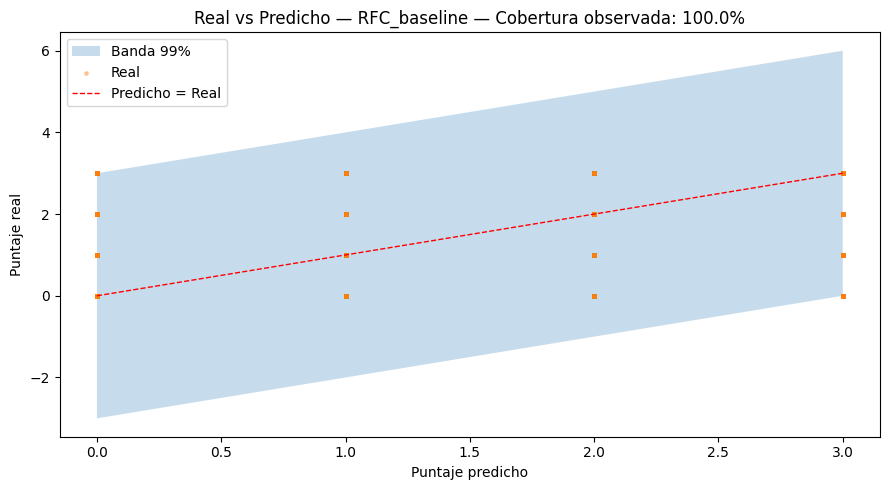

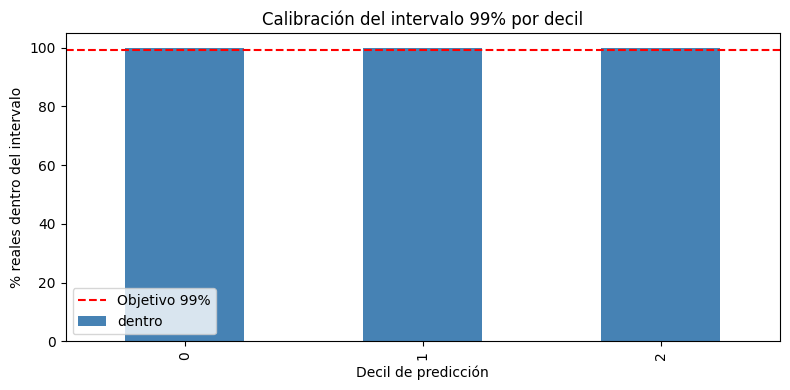

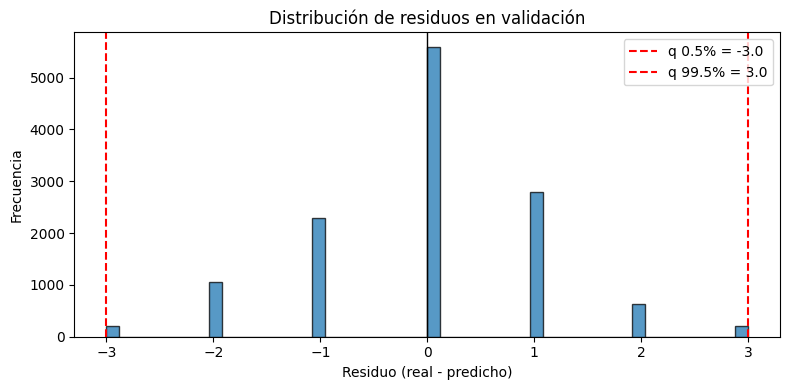

In [92]:
# 1) Real vs Predicho con banda al 99% en TEST
orden = np.argsort(pred_test_best)
fig, ax = plt.subplots(figsize=(9, 5))
ax.fill_between(pred_test_best[orden], lim_inf_test[orden], lim_sup_test[orden],
                alpha=0.25, label="Banda 99%")
ax.scatter(pred_test_best, y_test, s=6, alpha=0.35, label="Real")
lims = [min(y_test.min(), pred_test_best.min()), max(y_test.max(), pred_test_best.max())]
ax.plot(lims, lims, "r--", lw=1, label="Predicho = Real")
ax.set_xlabel("Puntaje predicho"); ax.set_ylabel("Puntaje real")
ax.set_title(f"Real vs Predicho — {mejor} — Cobertura observada: {cobertura_test:.1f}%")
ax.legend(); plt.tight_layout(); plt.show()

# 2) Calibración por decil de predicción
deciles = pd.qcut(pred_test_best, 10, labels=False, duplicates="drop")
calib = pd.DataFrame({"decil":deciles,
                     "dentro":(y_test>=lim_inf_test)&(y_test<=lim_sup_test)})
calib_pct = calib.groupby("decil")["dentro"].mean()*100
fig, ax = plt.subplots(figsize=(8, 4))
calib_pct.plot(kind="bar", ax=ax, color="steelblue")
ax.axhline(99, color="red", ls="--", label="Objetivo 99%")
ax.set_ylabel("% reales dentro del intervalo"); ax.set_xlabel("Decil de predicción")
ax.set_title("Calibración del intervalo 99% por decil")
ax.legend(); plt.tight_layout(); plt.show()

# 3) Distribución de residuos
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(residuos_val, bins=50, edgecolor="black", alpha=0.75)
ax.axvline(q_low, color="red", ls="--", label=f"q 0.5% = {q_low:.1f}")
ax.axvline(q_high, color="red", ls="--", label=f"q 99.5% = {q_high:.1f}")
ax.axvline(0, color="black", lw=1)
ax.set_xlabel("Residuo (real - predicho)"); ax.set_ylabel("Frecuencia")
ax.set_title("Distribución de residuos en validación"); ax.legend()
plt.tight_layout(); plt.show()

In [ ]:
from sklearn.ensemble import HistGradientBoostingClassifier

config_gbm = [
    {"name":"GBM_conservador", "max_depth":5, "lr":0.05, "max_iter":600, "min_samples_leaf":80, "l2":1.0},
    {"name":"GBM_balanceado",  "max_depth":7, "lr":0.05, "max_iter":800, "min_samples_leaf":50, "l2":0.5},
    {"name":"GBM_flexible",    "max_depth":9, "lr":0.03, "max_iter":1200,"min_samples_leaf":30, "l2":0.1},
]
gbm_results = {}
for cfg in config_gbm:
    with mlflow.start_run(run_name=cfg["name"]):
        gbm = HistGradientBoostingClassifier(
            max_iter=cfg["max_iter"], max_depth=cfg["max_depth"],
            learning_rate=cfg["lr"], l2_regularization=cfg["l2"],
            min_samples_leaf=cfg["min_samples_leaf"],             
            early_stopping=True, validation_fraction=0.15, n_iter_no_change=25,
            random_state=semilla)
        gbm.fit(X_train, y_train)
        
        # Diagnóstico de sobreajuste: train vs val vs test
        m_tr  = evaluar_clasif(y_train, gbm.predict(X_train), gbm.predict_proba(X_train), f'{cfg["name"]} TRAIN')
        m_val = evaluar_clasif(y_val,   gbm.predict(X_val),   gbm.predict_proba(X_val),   f'{cfg["name"]} VAL  ')
        m_test= evaluar_clasif(y_test,  gbm.predict(X_test),  gbm.predict_proba(X_test),  f'{cfg["name"]} TEST ')
        
        mlflow.log_params({**{k:v for k,v in cfg.items() if k!="name"}, "model_type":"HistGBMClassifier"})
        for k,v in m_val.items():  mlflow.log_metric(f"val_{k}", v)
        for k,v in m_test.items(): mlflow.log_metric(f"test_{k}", v)
        mlflow.log_metric("gap_F1_train_val", m_tr["F1_macro"] - m_val["F1_macro"])  # >0.05 = sobreajuste
        mlflow.sklearn.log_model(gbm, name=cfg["name"])
        gbm_results[cfg["name"]] = (gbm, m_val, m_test, m_tr)

  [GBM_conservador TRAIN]  Acc=0.447 | F1m=0.431 | Adj_pm1=0.846 | AUC=0.757
  [GBM_conservador VAL  ]  Acc=0.406 | F1m=0.388 | Adj_pm1=0.834 | AUC=0.708
  [GBM_conservador TEST ]  Acc=0.415 | F1m=0.395 | Adj_pm1=0.841 | AUC=0.719


2026/05/24 12:49:15 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


  [GBM_balanceado TRAIN]  Acc=0.464 | F1m=0.446 | Adj_pm1=0.848 | AUC=0.770
  [GBM_balanceado VAL  ]  Acc=0.410 | F1m=0.390 | Adj_pm1=0.834 | AUC=0.707
  [GBM_balanceado TEST ]  Acc=0.421 | F1m=0.400 | Adj_pm1=0.841 | AUC=0.719


2026/05/24 12:49:42 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


  [GBM_flexible TRAIN]  Acc=0.461 | F1m=0.445 | Adj_pm1=0.848 | AUC=0.771
  [GBM_flexible VAL  ]  Acc=0.408 | F1m=0.389 | Adj_pm1=0.833 | AUC=0.707
  [GBM_flexible TEST ]  Acc=0.418 | F1m=0.398 | Adj_pm1=0.838 | AUC=0.719


2026/05/24 12:50:02 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
